**Autor:** Gabriel César Tavares Ferreira

# Bussiness Understanding

## Objetivo de Negócio

O objetivo do projeto minimizar o número de fraudes em transações de cartões de forma precisa, sem prejudicar a experiência de clientes legítimos. Portanto a otimização busca reduzir ao máximo fraudes, e tentando manter a taxa de bloqueios indevidos para compras legítimas em um nível aceitável. 

## Objetivo do Modelo

Estamos tratando de um problema de Aprendizado Supervisionado de Classificação binária. O modelo deve aprender a partir dos dados fornecidos para prever a probabilidade de um transação ser ou não fraudulenta.

# Data Understanding

## Imports e Carregamento do dataset

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc
import os

In [25]:
df = pd.read_csv('../data/dataset.csv')

## Análise Inicial do Dados

Etapa de análise inicial do dataset

In [26]:
df.shape #Verificar o formato do nosso dataset

(1000000, 8)

In [27]:
df.head() #Verificar como estão os dados nesse dataset

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


## Estatísticas descritivas

Vamos primeiro gerar um resumo estatístico para as colunas númericas

In [28]:
df.describe() #Gerar estatísticas descritivas para as nossas colunas

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [29]:
df.info() #Resumo descritivo sobre cada coluna do nosso dataset

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


Podemos observar, que o dataset possui 1 milhão de observações e 8 colunas e todas as colunas tem o mesmo tipo de dados ``float64``. Mas observando o comportamento de ``repeat_retailer`` ,``used_chip``, ``used_pin_number``, ``online_order`` e ``fraud`` no dataset, podemos perceber que se tratam de colunas categóricas, então uma padronização que podemos fazer na etapa de Data Preparation, é a conversão dessas colunas para o tipo inteiro, para melhor separação dessas classes e por consumir menos espaço de memória.

Agora vamos avaliar a completude e qualidade do nosso dataset fazendo alguns testes.

In [30]:
df.isnull().sum() #verificação da existência de valores ausentes no dataset

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [31]:
df.duplicated().sum() #Verificação de valores duplicados no dataset

np.int64(0)

Com esses dois testes, observamos que não temos valores ausentes e nem duplicados. Para um terceiro teste, vamos verrificar se os valores dos dados númericos fazem sentido. Vamos verificar se não temos valores que saiam do padrão esperados para eles. No caso das colunas númericas, não podemmos ter valores negativos para distâncias e compras, e para as colunas categóricas, não podemos ter valores diferentes de 0 e 1. O metódo ``.describe()`` já nós dá essa dica, mas para fins de confirmação, vamos fazer uma lógica simples para confirmar.

In [32]:
cols_num = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price'] #colunas númericas
cols_cat = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud'] #colunas categóricas

#verificação de colunas númericas
for col in cols_num:
    if df[col].min() < 0:
        print(f'{col}:valor negativo')
    else:
        print(f'{col}:sem negativos')

#verificação de colunas categóricas
for col in cols_cat:
    freak = df[~df[col].isin([0,1])]
    if len(freak) > 0:
        print(f'{col}: valor estranho')
    else:
        print(f'{col}: ok')

distance_from_home:sem negativos
distance_from_last_transaction:sem negativos
ratio_to_median_purchase_price:sem negativos
repeat_retailer: ok
used_chip: ok
used_pin_number: ok
online_order: ok
fraud: ok


O metódo ``.describe()`` nos mostra, também, a média e mediana de cada coluna do nosso dataset, mas caso nosso dataset tenha um desbalanceamento na proporção do nosso target ``fraud``, essa medida global pode acabar "engolindo" nossa informação sobre a classe minoritária. Vamos primeiro verificar o balanceamento do nosso dataset

In [33]:
df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%' #verificação de balanceamento

fraud
0.0    91.26%
1.0     8.74%
Name: proportion, dtype: str

Temos desbalanceamento moderado, então para ter um indicação precisa se temos ou não outliers, optei por dividir o dataset por ``fraud``.

In [34]:
comparativo = df.groupby('fraud')[cols_num].agg(['mean', 'median', 'std'])
comparativo = comparativo.T #transposta apenas para formatação para melhor leitura 

print(comparativo)

fraud                                        0.0         1.0
distance_from_home             mean    22.832976   66.261876
                               median   9.673847   15.454219
                               std     52.828655  134.391608
distance_from_last_transaction mean     4.301391   12.712185
                               median   0.985074    1.157631
                               std     22.472359   47.997697
ratio_to_median_purchase_price mean     1.423642    6.006323
                               median   0.913950    5.071294
                               std      1.946152    5.564320


Com essa divisão temos algumas informações importantes. A média em casos normais (não fraude) é maior que a mediana, por mais que isso seja um sinal de outlier em estatística, se tratando de comportamento de transações, podemos considerar que existem esses tipos de transações de forma autêntica (uma viagem, emergência, etc). Por isso é natural que a média seja puxada um pouco para cima. Já no caso de fraude, a a distância é brutalmente maior, já que podemos interpretar que o objetivo do fraudador é diferente, esvaziar o limite o mais rápido possível por exemplo. Isso confirma que a fraude não segue o padrão de consumo habitual de usuários, gerando outliers extremos que distorcem completamente a média e mediana da classe.

## Análise Exploratória

Nessa etapa, queremos uma análise mais minuciosa dos nossos dados, mostrando gráficos, tabelas, medidas resumo e outros métodos. Esse item será dividido em três tipos de análise: univariada, bivariada e multivarida.

### Univariada

Para a análise univariada de variáveis categóricas foi realizado um estudo de contagem de valores

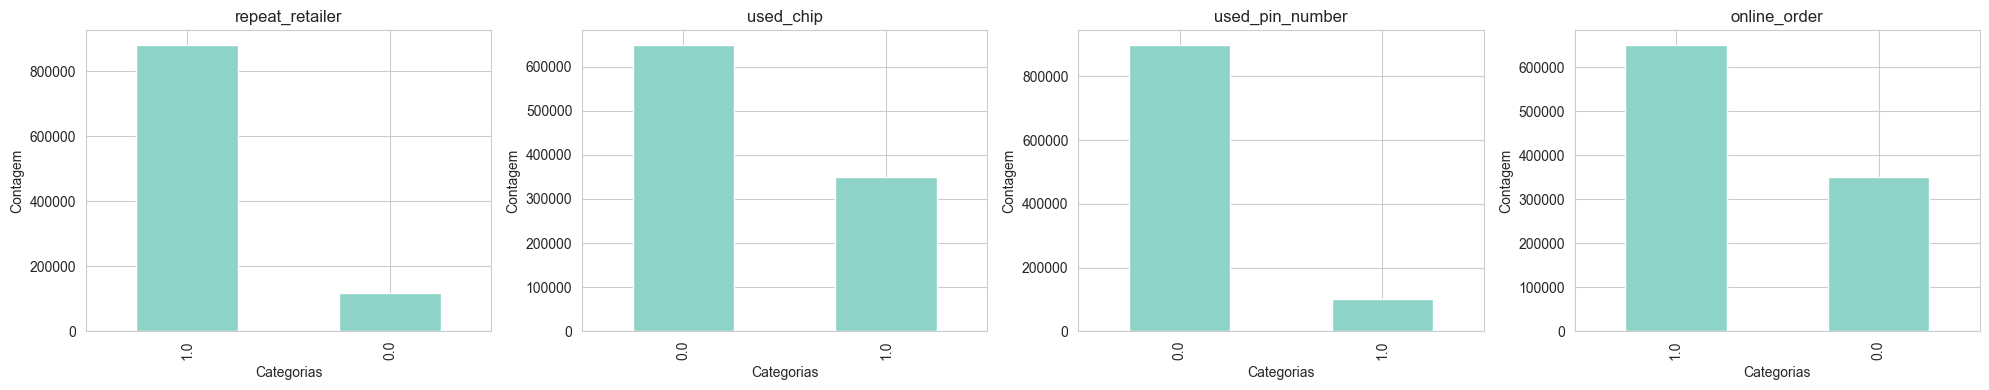

In [35]:
plt.figure(figsize=(20, 4))
cols_cat = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order'] #colunas categóricas

for i, col in enumerate(cols_cat, 1):
    plt.subplot(1, 4, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.xlabel('Categorias')
    plt.ylabel('Contagem')

plt.tight_layout()
plt.show()

Para as variáveis númericas foram feitas análise gráficas

### Análise Bivariada

Após o entendimento individual de cada variável é necessário entender a relação entre elas. Sendo assim, vamos analisar a relação de cada variável com nosso ``target``.

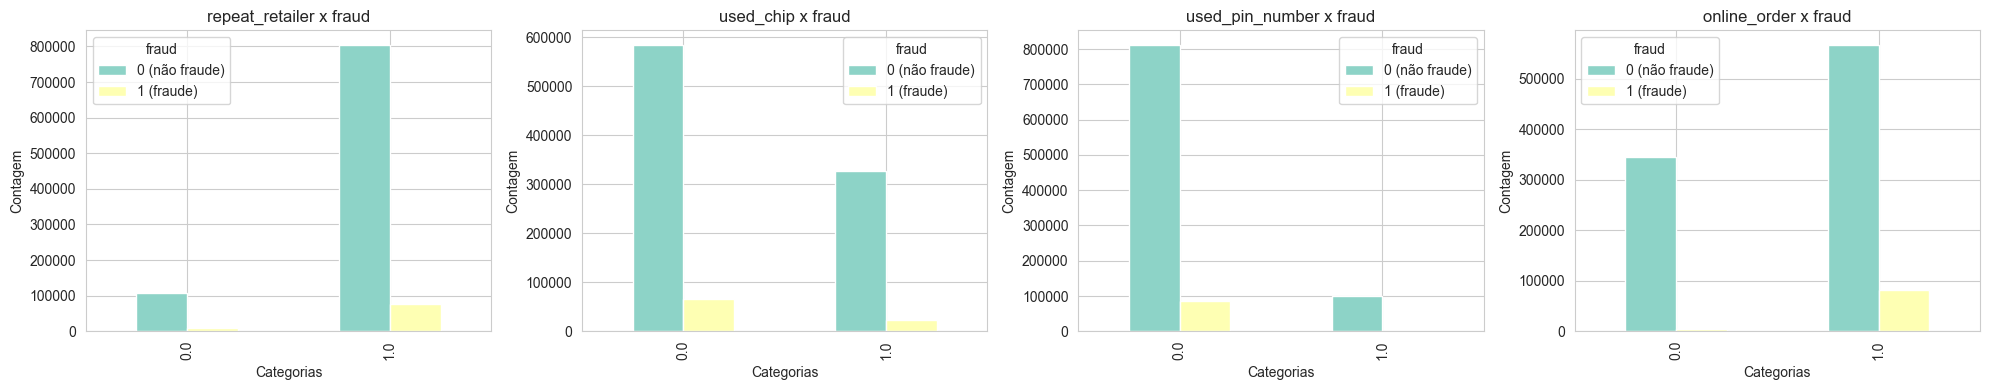

In [36]:
plt.figure(figsize=(20, 4))

for i, col in enumerate(cols_cat, 1):
    plt.subplot(1, 4, i)
    cross = pd.crosstab(df[col], df['fraud'])
    cross.plot(kind='bar', ax=plt.gca())
    plt.title(f'{col} x fraud')
    plt.xlabel('Categorias')
    plt.ylabel('Contagem')
    plt.legend(title='fraud', labels=['0 (não fraude)', '1 (fraude)'])

plt.tight_layout()
plt.show()

Com essa informação podemos perceber que compras feitas online e compras que não usam senha, tem uma grande quantidade de transações fraudulentas

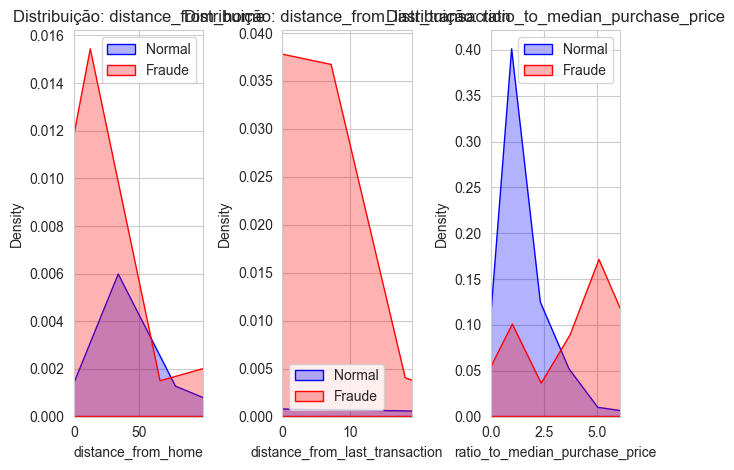

In [37]:
sns.set_style("whitegrid")
for i, col in enumerate(cols_num):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(df[df['fraud']==0][col], label='Normal', fill=True, color='blue', alpha=0.3)
    sns.kdeplot(df[df['fraud']==1][col], label='Fraude', fill=True, color='red', alpha=0.3)
    plt.title(f'Distribuição: {col}')
    plt.legend()
    plt.xlim(0, df[col].quantile(0.95)) 

plt.tight_layout()
plt.show()

No gráfico de distribuição de ``ratio_to_median_purchase_price``, podemos notar um grande ponto de atenção, que o pico de transaçãoes legitímas, fica em torno de de 1, enquanto a de transações fraudulentas é 5x maior.  

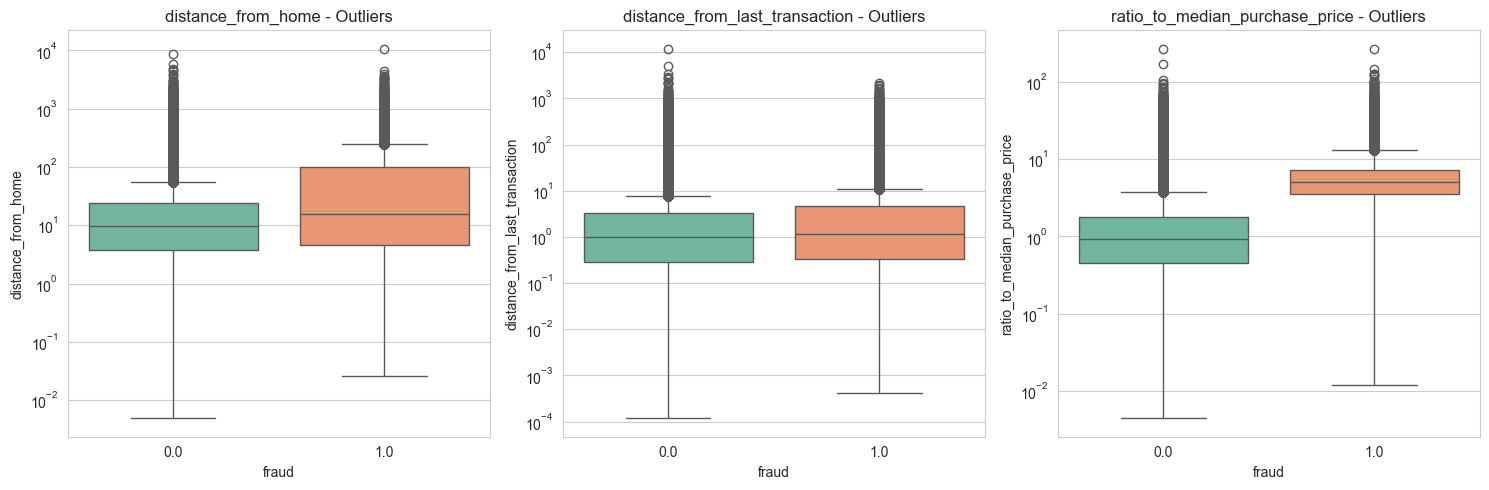

In [38]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_num):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='fraud', y=col, data=df, hue='fraud', legend=False, palette='Set2')
    plt.title(f'{col} - Outliers')
    plt.yscale('log')
    
plt.tight_layout()
plt.show()

Em ``distance_from_home`` podemos ver que a mediana de transações fraudulentas é maior que a de não fraudeulentas. Mas a maior discrepancia que podemos ver é em ``ratio_to_median_purchase_price`` onde a mediana de compra fraudulentas é maior que a média de compras legitímas.

### Análise Multivariada

A análise muitivariada é uma extensão da análise bivarida, que vai nos permitir investigar e compreender as relações entre três ou mais variáveis.

Na análise de variávies categóricas, acabei identificando um padrão estranho em relação as categorias ``repeat_retailer`` ,``used_chip``, ``used_pin_number`` e ``online_order``. Percebi que a existência de compras feitas online que usam chip. Então decidi fazer uma tabela lógica para enxergar a combinação dessas categorias:


|``repeat_retailer``|``used_chip``|``used_pin_number``|``online_order``| tipo de compra|
|-|-|-|-|--|
|0|0|0|0|Contacless|
|0|0|0|1|Online|
|0|0|1|0|Contactless + senha|
|0|0|1|1|Online + autenticação|
|0|1|0|0|Chip + assinatura|
|0|1|0|1|Token + online|
|0|1|1|0|Inserção + senha|
|0|1|1|1|Anomalia|
|1|0|0|0|Contactless|
|1|0|0|1|Online|
|1|0|1|0|Contactless + senha|
|1|0|1|1|Online + autenticação|
|1|1|0|0|Chip + assinatura|
|1|1|0|1|Token + online|
|1|1|1|0|Inserção + senha|
|1|1|1|1|Anomalia|

Para classficar compras que usam chip e são online, ``1101`` e ``0101``, foram feitas algumas pesquisas, e encontrei a informação que algumas comprar online que usam, por exemplo, Apple Pay/Samsung Pay, o sistema transmite um "token" que se comporta digitalmente como um chip seguro. Já para classificar compras feitas usando chip sem a necessidade de senha, ``0100`` e ``1100``, também foi feita um pesquisa e encontrei a informação de que em alguns países, EUA por exemplo, ou em cartões específicos, a pessoa insere o chip, mas em vez de digitar a senha, a máquina imprime um recibo para pessoa assinar. Jé em relação a compra online, com inserção e senha, ``0111`` e ``1111``, não consegui achar nehuma informação, então classifiquei como Anomalia.

Por fim, vamos verificar, qual combinação de categorias tem a maior frequência de fraudes.

In [39]:
analise_recorrencia = df.groupby(['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order'])['fraud'].agg(
    Total_Transacoes='count',
    Total_Fraudes='sum',
    Taxa_Fraude='mean'
).reset_index()

analise_recorrencia['Taxa_Fraude'] = (analise_recorrencia['Taxa_Fraude'] * 100).round(2)

print(analise_recorrencia.sort_values(by='Taxa_Fraude', ascending=False))

    repeat_retailer  used_chip  used_pin_number  online_order  \
9               1.0        0.0              0.0           1.0   
5               0.0        1.0              0.0           1.0   
1               0.0        0.0              0.0           1.0   
13              1.0        1.0              0.0           1.0   
0               0.0        0.0              0.0           0.0   
12              1.0        1.0              0.0           0.0   
8               1.0        0.0              0.0           0.0   
11              1.0        0.0              1.0           1.0   
7               0.0        1.0              1.0           1.0   
3               0.0        0.0              1.0           1.0   
4               0.0        1.0              0.0           0.0   
14              1.0        1.0              1.0           0.0   
15              1.0        1.0              1.0           1.0   
2               0.0        0.0              1.0           0.0   
6               0.0      

Podemos perceber que as 5 combinações com maior taxa de fraudes, 4 delas possuem ``online_order``. 


|``repeat_retailer``|``used_chip``|``used_pin_number``|``online_order``| tipo de compra| Taxa de Fraude|
|-|-|-|-|--|--|
|0|0|0|0|Contacless|10.22%|
|0|0|0|1|Online|11.49%|
|0|0|1|0|Contactless + senha|0%|
|0|0|1|1|Online + autenticação|0.16%|
|0|1|0|0|Chip + assinatura|0.12%|
|0|1|0|1|Token + online|11.62%|
|0|1|1|0|Inserção + senha|0%|
|0|1|1|1|Anomalia|0.21%|
|1|0|0|0|Contactless|0.79%|
|1|0|0|1|Online|16.62%|
|1|0|1|0|Contactless + senha|0%|
|1|0|1|1|Online + autenticação|0.68%|
|1|1|0|0|Chip + assinatura|0.82%|
|1|1|0|1|Token + online|10.37%|
|1|1|1|0|Inserção + senha|0.01%|
|1|1|1|1|Anomalia|0.01%|

Para a análise muultivariada, queremos ver o comportamento da distância de cada do usuário, com sua valor e sua relação com nosso ``target``.

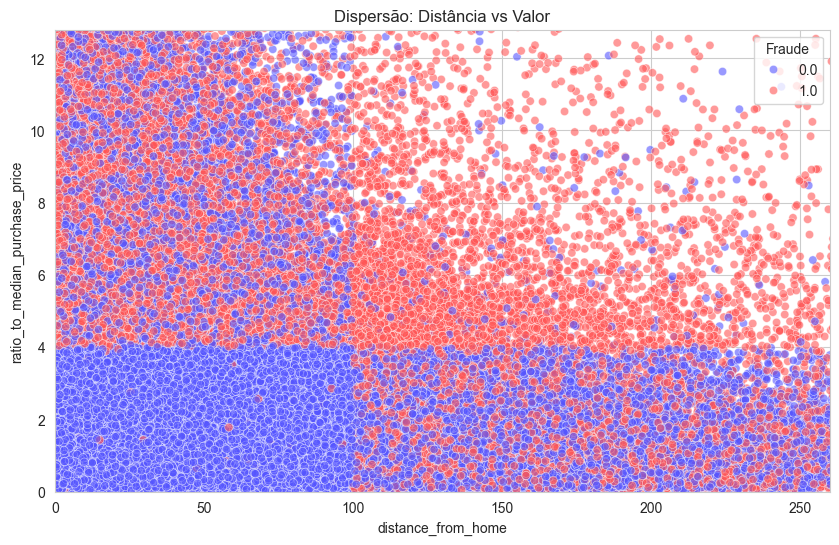

In [40]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='distance_from_home', 
    y='ratio_to_median_purchase_price', 
    hue='fraud', 
    palette='seismic',
    alpha=0.6
)

plt.title('Dispersão: Distância vs Valor')
plt.xlim(0, df['distance_from_home'].quantile(0.99)) 
plt.ylim(0, df['ratio_to_median_purchase_price'].quantile(0.99)) 
plt.legend(loc='upper right', title='Fraude')

plt.show()

Esse gráfico revelou que transações que combinam distâncias mais longas e valores muito acima da mediana são quase todas fraude. Podemos observar que um comportamento legítimo se encontra mais concetrado na parte inferior do gráfico.

Por último vamos analisar a matriz de correlação entre todas as variáveis.

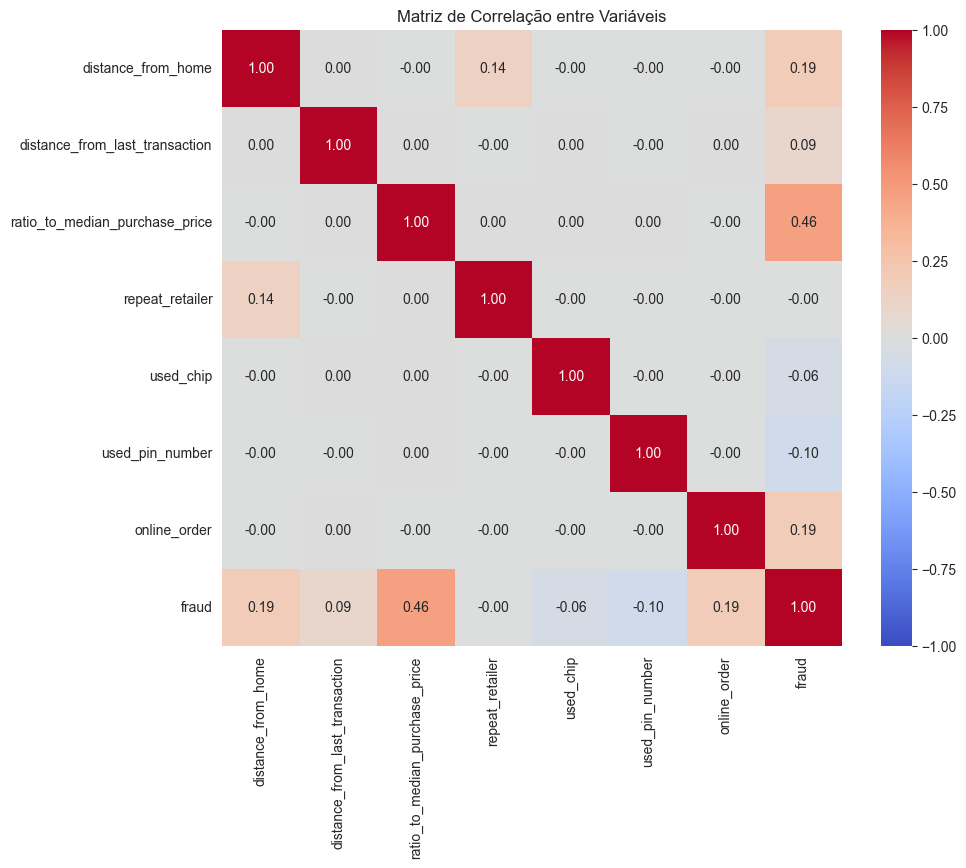

In [41]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Variáveis')
plt.show()

Essa matriz nos mostra que correlação entre ``fraud `` e ``ratio_to_median_purchase_price`` é alta, o que significa que é o valor da compra é um forte indicador de fraude.

# Data Preparation

Nessa etapa os dados brutos são transformados em um formato adequado para modelagem.

## Tratamento de Valores Nulos

Identificamos na sessão de data understanding, que não possuimos valores nulos no dataset, então podemos pular essa etapa.

## Codificação de variávies categóricas

Como mencionado na etapa anterior, optei pela criação da variável ``risk_score``

In [42]:
def definir_score_risco(row):
    if (row['online_order']==1) and (row['used_pin_number']==0) and (row['used_chip']==0) and (row['repeat_retailer']==0):
        return 4 
    elif (row['used_pin_number']==0) and (row['used_chip']==0): 
        return 3 
    elif (row['used_pin_number']==1) and (row['used_chip']==1):
        return 1 
    else:
        return 2 

df['risk_score'] = df.apply(definir_score_risco, axis=1)

Como, também, mencionado anteriormente, vamos fazer a conversão do tipo da variáveis categóricas para o tipo ``int64``.

In [43]:
cols_para_converter = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']

for col in cols_para_converter:
    df[col] = df[col].astype(int)

## Separação de Treino e Teste

Como temos um base de dados grande, optei pela divisão de 80% total da base de dados para treinamento e 20% para treinamento.

In [44]:
X = df.drop(columns=['fraud'])
y = df['fraud']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

## Normalização e Padronização

Como estamos lidando com valores muitos discrepantes para distâncias e valores, precisamos colocar esses valores na mesma "régua", para usá-los em algoritmos matemáticos. Optei por utilizar ``StandardScaler`` para que todos tenham o mesmo peso matemático.

In [46]:
cols = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

scaler = StandardScaler()

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

In [47]:
X_train.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,risk_score
775819,0.308616,-0.139491,-0.477349,1,0,0,1,3
137608,-0.362284,0.016979,0.344777,1,0,0,1,3
114104,-0.289833,-0.160263,-0.281914,1,1,0,1,2
235375,-0.201289,-0.185320,-0.472985,1,0,0,0,3
591902,-0.164698,-0.103868,0.456508,1,0,0,0,3


# Modeling

Nessa fase, o objetivo é identificar o modelo que oferece o melhor desempenho preditivo ou descritivo para o nosso problema. Para selecionar quais técnicos de modelagem utilizar, precisamos entender qual o problema está sendo discutido, e isso vimos na etapa de **Bussines Understanding**. Sendo assim, foram escolhidos 2 tipos de de modelos para serem feitos:

1. **Logistic Regression**: Cumpre o papel de ser um modelo simples, mas não foi escolhido por esperar o melhor resultado, mas para servir de base de performace para nosso modelo mais complexo, além de ser um modelo leve.
2. **Random Forest Classifier**: Escolhida pela robustez em lidar com relações que não são lineares e interações mais complexas entre variáveis. Por ser um modelo baseado em árvores assemble, ele lida melhor com outliers.

Além disso, como já observamos temos um dataset desbalanceado, opetei pelo uso de ``class_weight='balanced'``. 

"**Por quê não usar SMOTE ?**" 

Já temos um dataset com 1 milhão de linhas, usar SMOTE, aumentaria ainda mais nosso dataset, tornando o treinamento pesado e lento, além de criar dados sintícos que podem atrapalhar no resultado do nosso modelo, já que estamos trantando de transações com cartão. Usar ``class_weight`` mantém os dados originais, mas faz com o que o modelo "preste mais atenção" nos dados minoritários.

In [48]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

In [49]:
auc_log = roc_auc_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)
acc_log = accuracy_score(y_test, y_pred_log)

print("AUC:", auc_log)
print("Precision:", prec_log)
print("Recall:", rec_log)
print("F1:", f1_log)
print("Confusion matrix:\n", cm_log)
print("Acurácia:", acc_log)

AUC: 0.9424134504511688
Precision: 0.5848398350777038
Recall: 0.9493736056289686
F1: 0.7237995551485019
Confusion matrix:
 [[170738  11781]
 [   885  16596]]
Acurácia: 0.93667


In [55]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

In [51]:
auc_rf = roc_auc_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("AUC:", auc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1:", f1_rf)
print("Confusion matrix:\n", cm_rf)
print("Acurácia:\n", acc_rf)

AUC: 0.9999141925519135
Precision: 1.0
Recall: 0.999828385103827
F1: 0.9999141851883635
Confusion matrix:
 [[182519      0]
 [     3  17478]]
Acurácia:
 0.999985


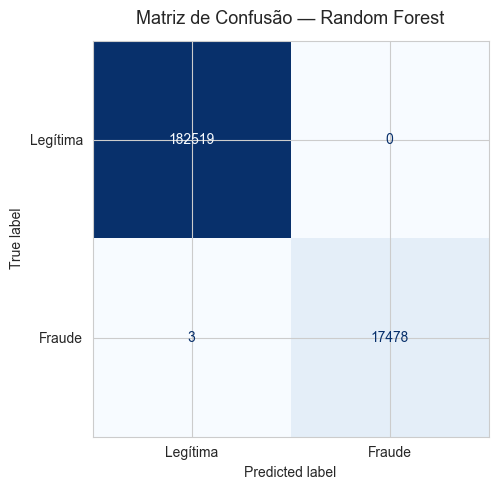

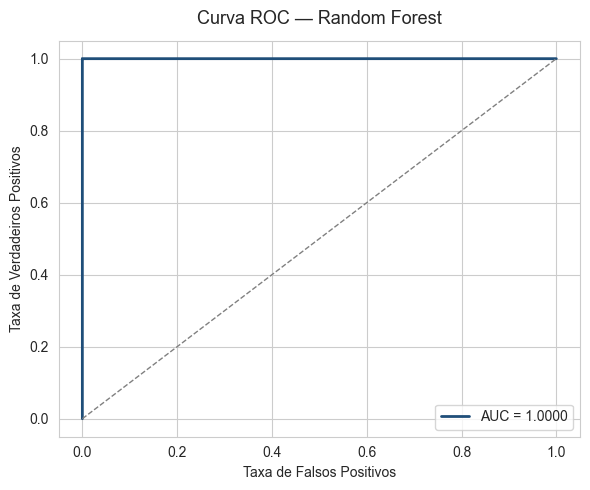

In [59]:
os.makedirs("images", exist_ok=True)

# --- Matriz de Confusão ---
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Legítima", "Fraude"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusão — Random Forest", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../images/confusion_matrix.png", dpi=150)
plt.show()

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#1F4E79", lw=2, label=f"AUC = {roc_auc:.4f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax.set_xlabel("Taxa de Falsos Positivos")
ax.set_ylabel("Taxa de Verdadeiros Positivos")
ax.set_title("Curva ROC — Random Forest", fontsize=13, pad=12)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../images/roc_curve.png", dpi=150)
plt.show()

# Evaluation

Nessa etapa é avaliada se os modelos desenvolvidos satisfazem os requisitos e objetivos do projeto.

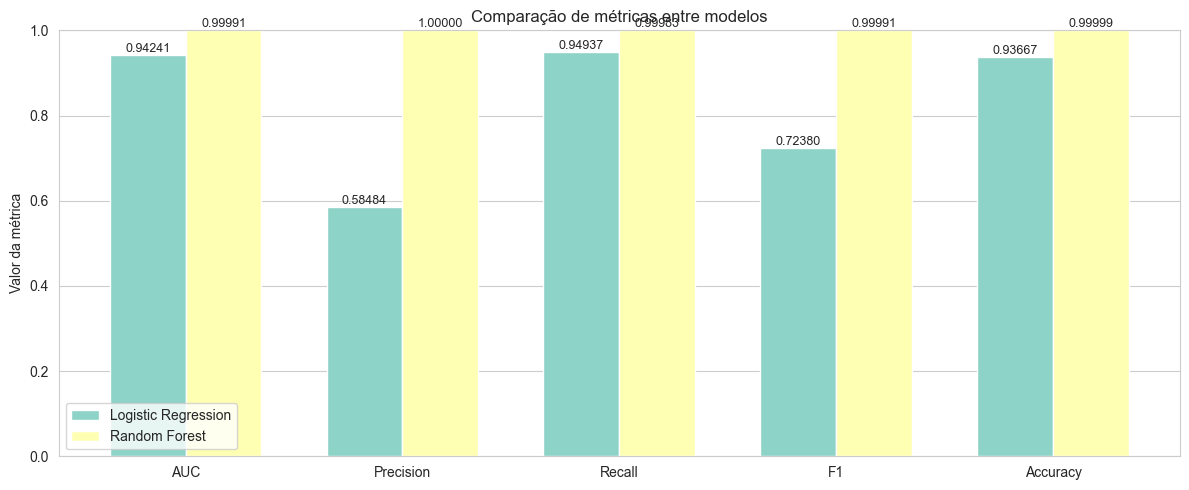

In [52]:
metricas = ['AUC', 'Precision', 'Recall', 'F1', 'Accuracy']
log_vals = [auc_log, prec_log, rec_log, f1_log, acc_log]
rf_vals = [auc_rf, prec_rf, rec_rf, f1_rf, acc_rf]
x = np.arange(len(metricas)) 
width = 0.35  
plt.figure(figsize=(12, 5))

bars1 = plt.bar(x - width/2, log_vals, width, label='Logistic Regression')
bars2 = plt.bar(x + width/2, rf_vals, width, label='Random Forest')

plt.ylabel('Valor da métrica')
plt.title('Comparação de métricas entre modelos')
plt.xticks(x, metricas)
plt.ylim(0, 1)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f'{y:.5f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

Como esperado, o modelo de Random Forest teve maior desempenho em todas as métricas.

### Escolha para Produção

Por questões de melhores resultados e performace, o modelo escolhida para implementação seria o de Random Forest Classifier.

### Threshold

Na Regressão Logística, se aumentassemos o limiar, a precisão subiria, por conta de menos falsos positivos, mas o Recall cairia, perdendo algumas fraudes. Como a prioridade do negócio é reduzir fraudes, um limiar padrão ou até menor seria ideal. Já para o Random Forest não precisaria de ajustes, já que ele conseguiu atingir um precisão de quase perfeição.

### Sentido para o ponto de vista do negócio

Dados esse conclusões, podemos dizer que o modelo faz sentido para o negócio. Ele maximiza o Recall, zerando o prejuízo financeiro com fraudes no ambiente de teste, ao mesmo tempo que mantém uma precisão alta. 

# Deployment

Nessa etapa, como não é necessário a implementação de um sistema completo, apenas o raciocínio de deploy, vamos dividir o deploy empartes.

## Planejamento da Implantação

Temos um modelo que prever fraudes em transações de cartões, então temos um modelo que precisa está no ar o tempo todo. Então para esa etapa de planejamento, a proposta é a integração do modelo de **Random Forest Classifier**, que teve melhor resultado, ao motor de decisão da VOM. O modelo será encapsulado como uma API de microsserviço, que recebe os dados de uma transação, em formato ``JSON`` por exemplo, e retorna a saída do modelo antes da aprovação.

## Impacto de Negócio

Trazendo para o contexto de negócios, um dos objetivos do projeto era entender as variáveis principais para transações fraudulentas. Segundo nosso modelo a variável mais crítica foi ``ratio_to_median_purchase_price``, já que transações fraudulentas fogem drasticamente do padrão de consumo dos usuários. Outro ponto importante foi ``distance_from_home`` que provou, também, ser um grande discriminador de fraudes. A codificação da variável ``risk_score`` ajuda o modelo a distinguir esses pontos de atenção crítica. 

## Recomendações para Implementação

Por se tratar de um modelo que prever fraudes em transações de cartão, o modelo precisa ter várias instâncias da API com vários modelos do ar para aguentar uma grande quantidade de requisições. Como vamos ter várias instâncias do mesmo modelo, é preciso  garantir que eles tenham o mesmo pré processamento, o mesmo conjunto de features e a mesma versão do modelo usada nos testes.

## Monitorizaçaõ e Manutenção dos modelos

E por fim, para o monitorameento, é preciso que isso seja feito de forma contínua e o modelo não deve ser dado com finalizado. Como estratégias de fraudadores mudam o tempo todo, é preciso garantir que o modelo mantenha a perfomace e precisão quanto as previsões. Caso o modelo  comece a apresentar Data Drift, a recomendação é que o modelo seja reavaliado.